# <a id='toc1_'></a>[Digital signal processing. Lab0](#toc0_)

In [108]:
%%capture 
%pip install matplotlib 
%pip install numpy
%pip install seaborn

**Table of contents**<a id='toc0_'></a>    
- [Digital signal processing. Lab0](#toc1_)    
  - [Task1](#toc1_1_)    
  - [Task2](#toc1_2_)    
  - [Task3](#toc1_3_)    
  - [Task4](#toc1_4_)    
  - [Task5](#toc1_5_)    
    - [task5.4](#toc1_5_1_)    
    - [task5.1](#toc1_5_2_)    
    - [task5.2](#toc1_5_3_)    
    - [task5.3](#toc1_5_4_)    
  - [Task6](#toc1_6_)    
  - [Task7](#toc1_7_)    
    - [task7.1](#toc1_7_1_)    
    - [task7.2](#toc1_7_2_)    
    - [task7.3](#toc1_7_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_1_'></a>[Task1](#toc0_)
Построить график функции: $y = x^5 - x^4 + x^3 + 1$.

In [109]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

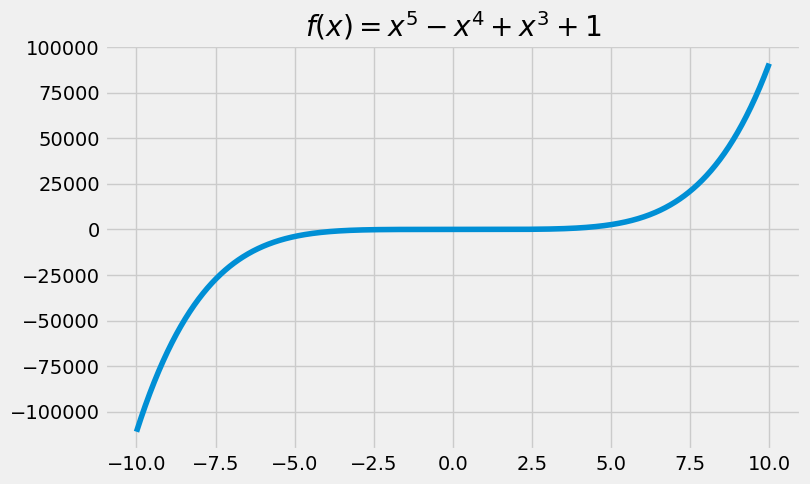

In [110]:
x = np.linspace(-10, 10, 1000)
y = x**5 - x**4 + x**3 + 1

plt.style.use('fivethirtyeight')

plt.figure(figsize=(8, 5))
plt.title(r'$f(x) = x^5 - x^4 + x^3 + 1$')
plt.plot(x,y)
plt.show()

## <a id='toc1_2_'></a>[Task2](#toc0_)
Построить график тангенса $y = \tan(x)$ на интервале от $-4\pi$ до $4\pi$.

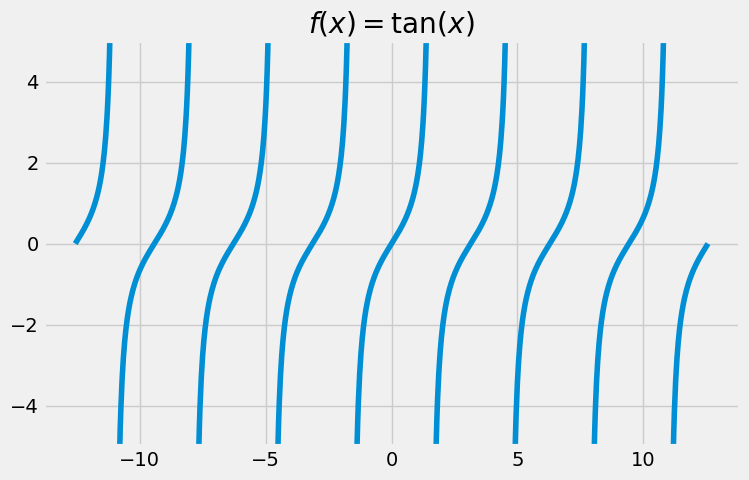

In [111]:
from numpy import pi 

x = np.linspace(-4*pi, 4*pi, 1000)
y = np.tan(x)

diff_y = np.diff(y, prepend=0)

y[diff_y<0] = np.nan

plt.figure(figsize=(8, 5))
plt.title(r'$f(x) = \tan(x)$')
plt.ylim(-5, 5)
plt.plot(x,y)
plt.show()

## <a id='toc1_3_'></a>[Task3](#toc0_)
Построить график окружности радиусом $R = 7$.

**Используем параметрическое уравнение окружности** :

$
\begin{cases}
   x = x_0 + R\cos t \\
   y = y_0 +R\sin t
\end{cases}
$, где $t \in [0, 2\pi]$

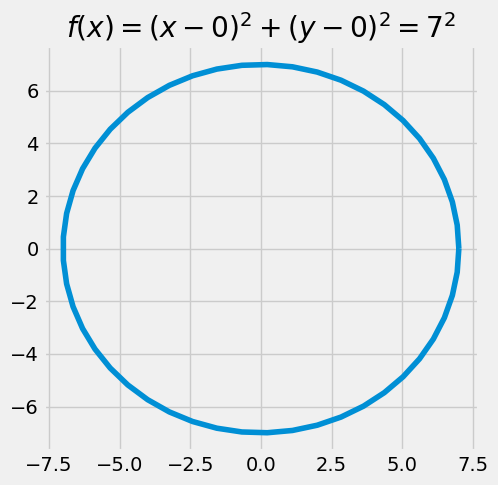

In [112]:
R = 7

t = np.linspace(0, 2*pi, endpoint=True)
x = R * np.cos(t)
y = R * np.sin(t)

plt.figure(figsize=(5, 5))
plt.title(r'$f(x) = (x-0)^2 + (y-0)^2 = 7^2$')
plt.plot(x,y)
plt.show()

## <a id='toc1_4_'></a>[Task4](#toc0_)
Вывести таблицу значений функции и построить её график на отрезке $[0, 1]$.

Функция:
$y(x) = \frac{5*\cos^2(x)}{3 + \sin(2x)}+ 4 *e^{-x}$

In [113]:
import pandas as pd

x = np.linspace(0,1, 100, endpoint=True)

y = (5*np.cos(x)**2)/(3 + np.sin(2*x)) + 4*np.exp(-x)

d = {'x' : x, 'y' : y}
data_table = pd.DataFrame(d, columns = ['x', 'y'])

data_table.head()

,x,y
0,0.000000,5.666667
1,0.010101,5.615150
2,0.020202,5.563856
3,0.030303,5.512789
4,0.040404,5.461954


## <a id='toc1_5_'></a>[Task5](#toc0_)
Построить график функции $f(x) = \exp(x)$. Разложение данной функции в ряд Тейлора записывается следующим образом:
$$f(x) = \sum_{k=0}^{\infty} \frac{x^k}{k!}$$

**Необходимо:**
1. Построить графики функции при разложении в ряд Тейлора для **5, 6 и 7-й степени**.
2. Вычислить значения функции при $x = 1.5$ и сравнить результат с `exp(1.5)`.
3. Вычислить значения функции при $x = 1 + i$ и сравнить результат с `exp(1 + 1j)`.
4. Реализовать предыдущие пункты через цикл `for`.

### <a id='toc1_5_1_'></a>[task5.4](#toc0_)

In [114]:
from math import factorial

def exp_teilor(x:float, degree:int = 7):
    exp_x = 0
    for i in range (degree + 1):
        exp_x +=x**i/factorial(i)
        #exp_x +=x**i/ np.prod([j for j in range(1,i+1)])
    return exp_x

### <a id='toc1_5_2_'></a>[task5.1](#toc0_)

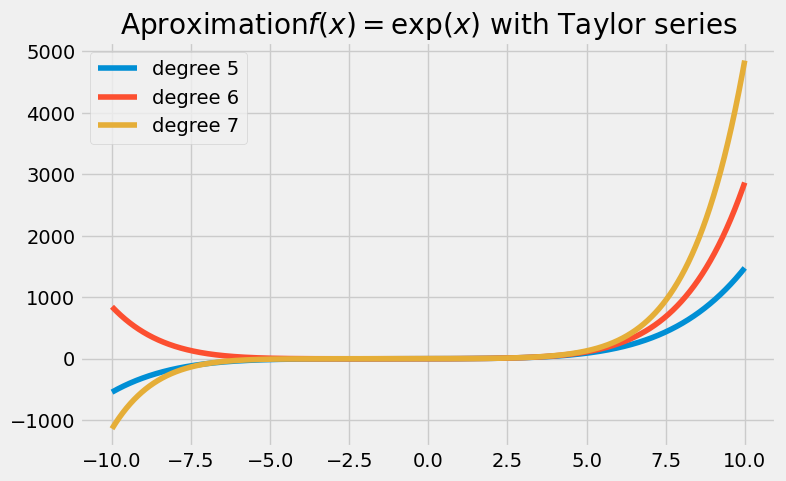

In [115]:
x = np.linspace(-10,10,10000)

y_5 = exp_teilor(x,5)
y_6 = exp_teilor(x,6)
y_7 = exp_teilor(x)

y = {"y_5" : y_5, 
     "y_6" : y_6,
     "y_7" : y_7,}

plt.figure(figsize=(8, 5))
plt.title(r'$\text{Aproximation} f(x) = \exp(x)\text{ with Taylor series}$')
plt.plot(x,y['y_5'], label = 'degree 5')
plt.plot(x,y['y_6'], label = 'degree 6')
plt.plot(x,y['y_7'], label = 'degree 7')

plt.legend()
plt.show()

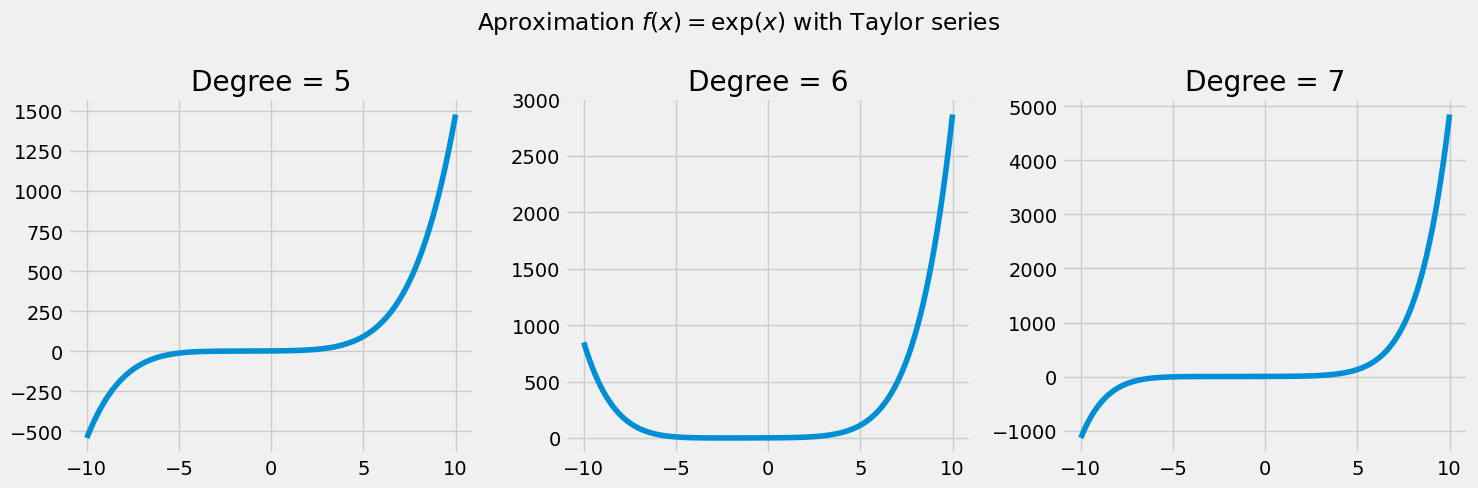

In [116]:
plt.figure(figsize=(15,5))

plt.suptitle(r'$\text{Aproximation } f(x) = \exp(x)\text{ with Taylor series}$')

for i in range (1,4):
    plt.subplot(1,3,i)
    degree = i + 4
    plt.title(f'Degree = {degree}')
    plt.plot(x,y[f'y_{degree}'])

plt.tight_layout()
plt.show()

### <a id='toc1_5_3_'></a>[task5.2](#toc0_)

In [117]:
from math import exp

x = 1.5
true_value = exp(x)

degrees = [5, 6, 7, 10, 20] 

for n in degrees:
    my_res = exp_teilor(x, n)
    
    error = abs(true_value - my_res)
    
    print(f"{n:<20} | {my_res:<20.10f} | {error:.5e}")

5                    | 4.4617187500         | 1.99703e-02
6                    | 4.4775390625         | 4.15001e-03
7                    | 4.4809291295         | 7.59941e-04
10                   | 4.4816865976         | 2.47279e-06
20                   | 4.4816890703         | 1.77636e-15


### <a id='toc1_5_4_'></a>[task5.3](#toc0_)

In [118]:
from cmath import exp

x = 1 + 1j
true_value = exp(x)

degrees = [5, 6, 7, 10, 20] 

for n in degrees:
    my_res = exp_teilor(x, n)
    
    error = abs(true_value - my_res)
    
    print(f"{n:<20} | {my_res:<20.10f} | {error:.5e}")

5                    | 1.4666666667+2.3000000000j | 1.28062e-02
6                    | 1.4666666667+2.2888888889j | 2.54200e-03
7                    | 1.4682539683+2.2873015873j | 4.43237e-04
10                   | 1.4686948854+2.2873544974j | 1.23195e-06
20                   | 1.4686939399+2.2873552872j | 8.88178e-16


## <a id='toc1_6_'></a>[Task6](#toc0_)
Реализовать разложение в ряд функции синуса $f(x) = \sin(x)$, используя цикл `for`.
Разложение данной функции в ряд Тейлора записывается следующим образом:
$$\sin(x) = \sum_{k=0}^{\infty} (-1)^k \frac{x^{2k+1}}{(2k+1)!}$$

**Необходимо:**
1. Построить графики функции при разложении в ряд Тейлора для **1, 3 и 7-й степени**.

In [119]:
def sin_teilor(x:float, degree:int = 7):
    sin_x = 0
    for i in range (degree + 1):
        sin_x +=(-1)**i * (x**(2*i + 1)) /factorial(2*i + 1)
    return sin_x

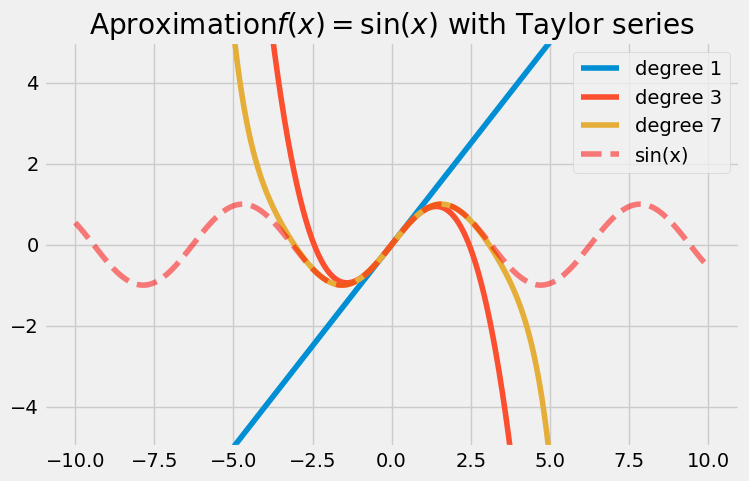

In [120]:
x = np.linspace(-10,10,10000)

y_1 = sin_teilor(x,0)
y_3 = sin_teilor(x,1)
y_7 = sin_teilor(x,3)

y = {"y_1" : y_1, 
     "y_3" : y_3,
     "y_7" : y_7,}

degrees = [1,3,7]

plt.figure(figsize=(8, 5))
plt.title(r'$\text{Aproximation} f(x) = \sin(x)\text{ with Taylor series}$')
plt.plot(x,y['y_1'], label = 'degree 1')
plt.plot(x,y['y_3'], label = 'degree 3')
plt.plot(x,y['y_7'], label = 'degree 7')
plt.plot(x, np.sin(x), 'r--', alpha=0.5, label = 'sin(x)')
plt.ylim(-5, 5)

plt.legend()
plt.show()

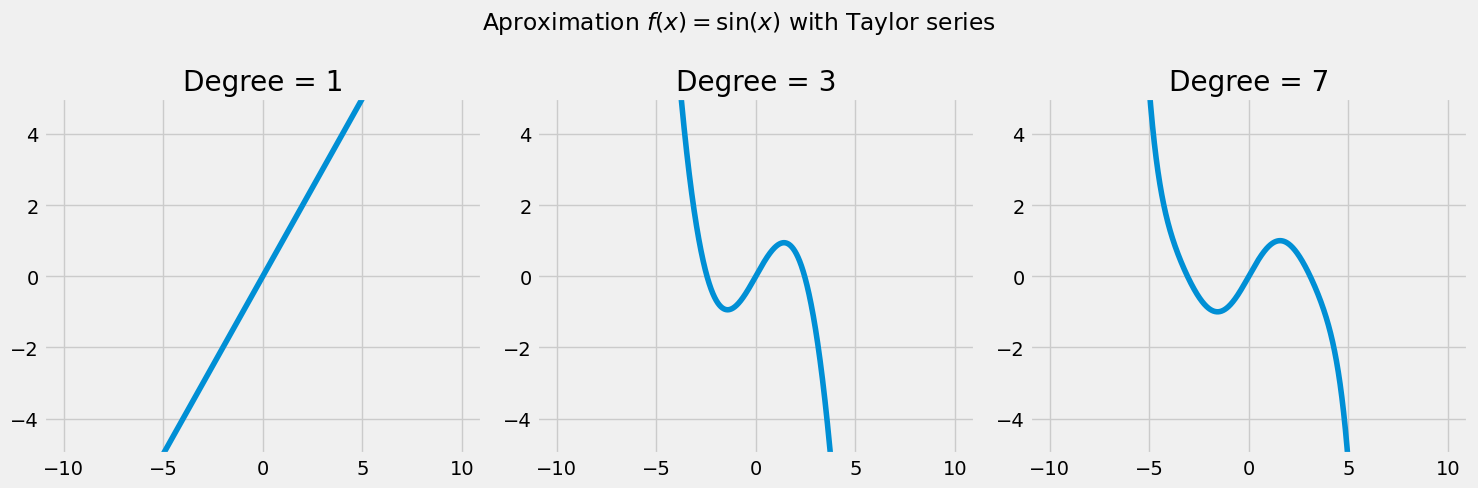

In [121]:
plt.figure(figsize=(15,5))

plt.suptitle(r'$\text{Aproximation } f(x) = \sin(x)\text{ with Taylor series}$')

for i,degree in enumerate(degrees):
    plt.subplot(1,3,i+1)
    plt.title(f'Degree = {degree}')
    plt.plot(x,y[f'y_{degree}'])
    plt.ylim(-5, 5)

plt.tight_layout()
plt.show()

## <a id='toc1_7_'></a>[Task7](#toc0_)
С помощью библиотеки **Pandas** реализовать:
1. Изменение данных столбца DataFrame по условию.
2. Изменение позиций столбцов объекта (поменять местами).
3. Замену пропущенных значений (`NaN`) в таблице средним значением.

In [162]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### <a id='toc1_7_1_'></a>[task7.1](#toc0_)

In [163]:
df.loc[df['sepal_length'] < 5.0, 'sepal_length'] = 100
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,100.0,3.0,1.4,0.2,setosa
2,100.0,3.2,1.3,0.2,setosa
3,100.0,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [164]:
df['sepal_width'] = df['sepal_width'].mask(df['sepal_width'] <=5, 5)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,5.0,1.4,0.2,setosa
1,100.0,5.0,1.4,0.2,setosa
2,100.0,5.0,1.3,0.2,setosa
3,100.0,5.0,1.5,0.2,setosa
4,5.0,5.0,1.4,0.2,setosa


### <a id='toc1_7_2_'></a>[task7.2](#toc0_)

In [165]:
new_order = ['species', 'sepal_width', 'sepal_length', 'petal_width', 'petal_length']
df = df[new_order]
df.head()

,species,sepal_width,sepal_length,petal_width,petal_length
0,setosa,5.0,5.1,0.2,1.4
1,setosa,5.0,100.0,0.2,1.4
2,setosa,5.0,100.0,0.2,1.3
3,setosa,5.0,100.0,0.2,1.5
4,setosa,5.0,5.0,0.2,1.4


### <a id='toc1_7_3_'></a>[task7.3](#toc0_)

In [166]:
df.iloc[0:3, 0] = np.nan 
df.iloc[2:5, 1] = np.nan
df.iloc[2:4, 3] = None
df.head()

,species,sepal_width,sepal_length,petal_width,petal_length
0,NaN,5.0,5.1,0.2,1.4
1,NaN,5.0,100.0,0.2,1.4
2,NaN,NaN,100.0,NaN,1.3
3,setosa,NaN,100.0,NaN,1.5
4,setosa,NaN,5.0,0.2,1.4


In [168]:
df.loc[df['petal_width'].isna(), 'petal_width'] = df['petal_width'].mean()
df.loc[df['sepal_width'].isna(), 'sepal_width'] = df['sepal_width'].mean()
df.loc[df['species'].isna(), 'species'] = df['species'].mode()[0]
df.head()

,species,sepal_width,sepal_length,petal_width,petal_length
0,versicolor,5.0,5.1,0.200000,1.4
1,virginica,5.0,100.0,0.200000,1.4
2,versicolor,5.0,100.0,1.212838,1.3
3,setosa,5.0,100.0,1.212838,1.5
4,setosa,5.0,5.0,0.200000,1.4
